# クリプトエコノミクス

## クリプトエコノミクスとは

**クリプトエコノミクス（cryptoeconomics）** は、暗号技術と経済的インセンティブを組み合わせて、管理者のいない分散システムで参加者に望ましい振る舞いをさせる仕組みの設計を指す。[エコノミクス](./index.ipynb) の整理でいえば **分散性のための合意形成の設計** にあたる。

用語は2014〜2015年頃からEthereumのコミュニティで使われ始めた。

- Vlad Zamfir（2015）：分散化されたデジタル経済における財・サービスの生産・分配・消費を統制するプロトコルを研究する形式的な学問であり、そのプロトコルの設計と特徴づけに焦点を当てる実践的な科学
- Vitalik Buterin（2015）：分散化されていて、認証に公開鍵暗号を使い、システムが動き続け、過去に巻き戻ったりしないことを経済的インセンティブで保証するもの

その後、学術的にも言及されるようになった。

- ミクロ経済学の一分野であるメカニズムデザインの一分野（Davidson, 2016）
- 「逆ゲーム理論」とも呼ばれるメカニズムデザインとの共通点が多い（Obasi, 2017）
- 経済学やゲーム理論の考え方を使ってP2Pの暗号システムを設計する、学際的で実験的な分野。インセンティブやペナルティで労力・財・サービスの配分を調整し、情報セキュリティ上の性質を保証しようとする（Brekke & Alsindi, 2021）

まとめると、**意見の集約（合意形成）の手段としてインセンティブ設計を使うこと** であり、学術的にはメカニズムデザインに位置づけられる。

## メカニズムデザインとの関係

```mermaid
flowchart LR
    micro["ミクロ経済学"] --> game["ゲーム理論<br/>ルールが与えられたとき<br/>プレイヤーはどう行動するか"]
    game --> md["メカニズムデザイン<br/>望ましい結果を得るには<br/>どんなルールを作ればよいか"]
    md --> amd["アルゴリズミック<br/>メカニズムデザイン"]
    cs["計算機科学"] --> amd
    amd --> damd["分散アルゴリズミック<br/>メカニズムデザイン"]
    damd -.-> crypto["クリプトエコノミクス"]
```

- **ゲーム理論**：ルール（ゲーム）が与えられたときに、合理的なプレイヤーがどう振る舞うか（均衡）を分析する
- **メカニズムデザイン**：逆に、達成したい結果を先に決め、プレイヤーが自分の利益を追求すると自然にその結果になるようなルールを設計する。オークション、マッチング、投票などが典型
- **アルゴリズミックメカニズムデザイン（AMD）**：メカニズムデザインを計算機科学の問題（ルーティング、負荷分散など）に応用する分野（Nisan & Ronen, 1999）。従来のメカニズムデザインでは考えない計算量などの制約も扱う
- **分散アルゴリズミックメカニズムデザイン（DAMD）**：AMDのうち、エージェント・計算資源・ネットワークが分散しているP2Pシステムに焦点を当てる（Feigenbaum et al., 2000）

DAMDの論点を整理したFeigenbaum & Shenker（2004）は、Ethereumの10年前に次のような未解決問題を挙げていた。

> **未解決問題10**：一部の参加者がルールに従順であると仮定しなければならない分散メカニズムを、デジタル署名（より一般には暗号プロトコルの設計技術）を使って、より現実的な戦略モデルを持つものに変換できるか？
>
> **未解決問題18**：純粋な物々交換型のP2Pシステムよりも性能の良い、貨幣を使うP2Pシステムを設計できるか？

BitcoinやEthereumは、まさにこれらの問いに実用的な答えを出したものといえる。

## Bitcoinの新規性

P2Pの電子現金の試みはBitcoin以前にもあった（b-money, 1998; Bit gold, 2005など）。しかし「ノード間で取引記録の意見が割れたときにどうするか」が長年の課題だった。

- ノードがいくつあるか分からない
- ノードは戦略的に嘘をつくかもしれない
- 悪意がなくても、故障や通信の失敗が起こる

Bitcoinは次の組み合わせで、この問題を（実用的なレベルで）解決した（→[コンセンサス](../blockchain/consensus.ipynb)）。

1. 台帳をブロックチェーンの形で管理する
2. 誰でもブロックを作れるが、作るには計算資源が必要（PoW）
3. 新しいブロックの作成者は、既存のどれか1つのブロックにつなぐ
4. 最長のチェーンに含まれるブロックを「正しい」記録とする（Nakamotoコンセンサス）
5. 「正しい」ブロックの作成者にBTCを新規発行する（coinbase）

「どこかの誰かが、自分の利益のために正しいブロックをつないでくれる」というインセンティブ設計の活用が、それまでの分散システムの研究とは違うアプローチだった。ただしファイナリティ（確定性）がないので、厳密な解決ではない（quasi-solution）。

この発想はEthereum（合意の対象を送金記録からプログラムの実行結果へ一般化）やThe DAOなどのDAppsに受け継がれ、それを表す言葉としてクリプトエコノミクスやトークノミクスが使われるようになった。

## 合意形成の3つの課題

分散的な合意形成を設計するうえでは、少なくとも次の3つの課題に対処する必要がある。

| 課題 | 内容 | ブロックチェーンでの典型的な対処 |
| --- | --- | --- |
| 戦略的行動 | 正しい情報を意図的に偽って報告する | PoW / PoS ＋ Nakamotoコンセンサス、トークンステーキングによる多数決 |
| スパム・シビル攻撃 | 無関係な内容を大量に送る / 1人で複数のIDを作る | トランザクション手数料、1 CPU 1票、1トークン1票 |
| ただ乗り | 貢献せずにシステムを利用する / 面倒なので適当に報告する | 多数派を支持した参加者への報酬（新規発行、再分配） |

### 戦略的行動

**戦略的行動** は、正しい情報を意図的に偽って報告すること。

- Bitcoinのノードは、矛盾するトランザクション（二重支払いなど）を含むブロックを作るかもしれない
- The DAOの利用者は、自分の提案に多くのETHが集まるように、本当に良いと思う投資先とは違う報告をするかもしれない

ブロックチェーンでは、合意形成を **資源による多数決** にすることで対処している。

- Bitcoin：PoW＋Nakamotoコンセンサスで、計算資源による多数決にした
- 多くのDApps：トークンステーキングで、トークンによる多数決にした

#### 経済学での扱い

メカニズムデザインでは、戦略的行動に強いメカニズムを次のように定式化する。

- **耐戦略性（strategy-proofness, truthfulness）**：どのプレイヤーも、虚偽の報告によって効用を増やせない。つまり正直な報告が（弱）支配戦略になっている
- **VCGメカニズム**（Vickrey–Clarke–Groves）：耐戦略性を含む複数の規範を満たすメカニズム。各プレイヤーは「自分がいることで他のプレイヤー全体が被った損失」を支払う。単一財のオークションでは第二価格オークションになる

#### ケインズの美人投票

DAppsの設計でおそらく最も重要な概念が **ケインズの美人投票** である。

- 複数の候補者のうち、最も票を集めた候補に投票したプレイヤーに賞金を出す
- するとプレイヤーは、自分が良いと思う候補ではなく「他のプレイヤーが何に投票しそうか」の予想に基づいて投票する
- 全員が同じ候補に投票する状態はどれもナッシュ均衡になるので、選択肢の数だけ均衡がある。プレイヤーの本当の信念は抽出できない

Bitcoinでも「他のノードがBlock Bにつなぎそうだから、自分もBlock Bにつなごう」という判断は美人投票そのものであり、多数派に報酬を与える仕組みには常にこの問題がある。それでもトークンステーキングによる多数決がよく使われるのは、

- 後述のスパム・シビル攻撃とただ乗りに対して有効だから
- 均衡が複数あっても、皆が自然に選ぶ点（**シェリングポイント**）として「真実」が選ばれるという主張があるから（Buterinの SchellingCoin, 2014）

である。

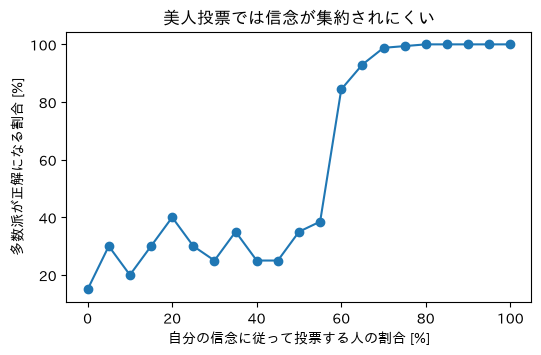

In [1]:
import matplotlib.pyplot as plt
import japanize_matplotlib  # noqa: F401
import numpy as np

rng = np.random.default_rng(0)


def beauty_contest(n_players: int, n_rounds: int, honest_share: float, n_options: int = 3) -> np.ndarray:
    # 各ラウンドで、honest_share の割合は自分の信念（正解=0を確率0.6で観測）に従って投票し、
    # 残りは前のラウンドの多数派に投票する。各ラウンドの多数派の選択肢を返す
    winners = []
    prev_winner = rng.integers(n_options)
    for _ in range(n_rounds):
        honest = rng.random(n_players) < honest_share
        signal = np.where(rng.random(n_players) < 0.6, 0, rng.integers(1, n_options, n_players))
        votes = np.where(honest, signal, prev_winner)
        prev_winner = np.bincount(votes, minlength=n_options).argmax()
        winners.append(prev_winner)
    return np.array(winners)


shares = np.linspace(0, 1, 21)
accuracy = [np.mean([(beauty_contest(100, 50, h) == 0).mean() for _ in range(20)]) for h in shares]

fig, ax = plt.subplots(figsize=(6, 3.5))
ax.plot(shares * 100, np.array(accuracy) * 100, marker="o")
ax.set(xlabel="自分の信念に従って投票する人の割合 [%]", ylabel="多数派が正解になる割合 [%]", title="美人投票では信念が集約されにくい")
plt.show()

自分の信念に従う人が少なく、多数派に追随する人が多いと、最初にたまたま選ばれた選択肢がそのまま固定され、正解が選ばれる保証がなくなる。

### スパム・シビル攻撃

- **スパム**：求められていない無関係な内容を拡散すること（Hayati et al., 2010）
- **シビル攻撃**：複数のIDを偽造すること（Douceur, 2002）

The DAOでいえば、無意味な提案を大量に出して合意形成を混乱させたり、1人で複数のアドレスを用意して投票したりすることにあたる。

ブロックチェーンでの対処は次のとおり。

- **スパム**：各トランザクションに小さなコストを課す伝統的な方法。トランザクション手数料（Bitcoin, Ethereum）、提案のデポジット（The DAO, Nouns DAO）
- **シビル攻撃**：投票力を個人やアカウントの数と独立な指標にする。1 CPU 1票（PoW）、1トークン1票（トークンステーキング、PoS）
- より直接的に **1人1票** を担保する試み（**proof of personhood**）もある。複数のSNSアカウントなどを提出させてスコア化するGitcoin Passport、虹彩による生体認証を使うWorld（旧Worldcoin）など

経済学では、スパム（Androutsopoulos et al., 2005; Reshef & Solan, 2006; Rao & Reiley, 2012）やシビル攻撃（Margolin & Levine, 2007など）のゲーム理論的なモデル化と、報酬・ペナルティ・手数料の効果の分析が行われているが、あまり活発な分野ではない。

### ただ乗り

**ただ乗り（free-riding）** は、システムに何も貢献せずにリソースを使うこと（Ramaswamy & Liu, 2003）。戦略的行動やシビル攻撃に対処できたとしても、人々は面倒なので合意形成に参加しなかったり、適当に同じ報告を繰り返したりするかもしれない。

ブロックチェーンでは「合意結果を支持した参加者に報酬を与える」ことで対処している。

- BTCやETHの新規発行（Bitcoin, Ethereum）
- 少数派のトークンを多数派に再分配する（トークンステーキング）。ただしゼロサムなので、参加のインセンティブとしては弱い

しかし、多数派に報酬を与えると美人投票の問題が起き、かといって参加者全員に報酬を与えると、報酬目当てに適当な報告をする人が出てくる。

#### 検証なしの情報抽出

一般的なメカニズムデザインは、投票やオークションのように「プレイヤーが報告すること」を暗黙の前提にしており、集まった情報をどうまとめるか（**情報集約**）を研究してきた。

一方、DAMDの文脈では、Amazonのレビューのように正解が後から確かめられない状況で、正直な報告を引き出す報酬の設計（**情報抽出**）が研究されてきた。これを **検証なしの情報抽出（Information Elicitation without Verification）** と呼ぶ。

- 参加者は、割り当てられたタスクから確率的に生じるシグナル（自分の評価）を報告する
- 集まった報告から計算される報酬を受け取る
- **受け取ったシグナルを正直に報告したときに報酬の期待値が最大になる** メカニズムを設計する

代表的なメカニズムに、ピア予測（Peer Prediction; Miller, Resnick & Zeckhauser, 2005）、ベイジアン真実自白剤（Bayesian Truth Serum; Prelec, 2004）、相関一致メカニズム（Correlated Agreement; Dasgupta & Ghosh, 2013）がある。

#### 相関一致メカニズム

Dasgupta & Ghosh（2013）のモデルを、2人の査読者 $i, j$ が複数の論文をaccept / rejectで評価する例で説明する。2人が同じ論文 $t$ を評価するたびに、次の報酬を受け取る。

$$
\underbrace{\delta(r_i^{t}, r_j^{t})}_{\text{同じ論文で一致したら報酬}} - \underbrace{\delta(r_i^{t'}, r_j^{t''})}_{\text{別々の論文で一致したらペナルティ}}
$$

ここで $\delta$ はクロネッカーのデルタ（一致すれば1、しなければ0）、$r_i^{t'}$ と $r_j^{t''}$ はそれぞれが過去に評価した別の論文からランダムに選んだ報告である。

- 「常にaccept」のように中身を見ずに同じ報告をすると、報酬項もペナルティ項も常に1になり、期待報酬は0
- ランダムに報告しても、報酬項とペナルティ項の期待値が等しく、期待報酬は0
- 正直に報告すると、同じ論文に対する2人の評価には相関があるので、報酬項の期待値がペナルティ項より大きくなり、期待報酬が正になる

つまり、正解を知らなくても「ちゃんと読んだ人どうしは意見が合いやすい」ことを利用して、手抜きを罰することができる。

In [2]:
def correlated_agreement(strategy_i: str, strategy_j: str, accuracy: float = 0.8, n_tasks: int = 100_000) -> float:
    # 各論文の真の評価（accept=1 / reject=0）に対し、査読者は確率 accuracy で正しいシグナルを受け取る
    truth = rng.integers(0, 2, n_tasks)

    def report(strategy: str) -> np.ndarray:
        signal = np.where(rng.random(n_tasks) < accuracy, truth, 1 - truth)
        return {"正直": signal, "常にaccept": np.ones(n_tasks, int), "ランダム": rng.integers(0, 2, n_tasks)}[strategy]

    r_i, r_j = report(strategy_i), report(strategy_j)
    reward = r_i == r_j  # 同じ論文での一致
    penalty = r_i[rng.permutation(n_tasks)] == r_j[rng.permutation(n_tasks)]  # 別々の論文での一致
    return (reward.astype(float) - penalty).mean()


strategies = ["正直", "常にaccept", "ランダム"]
print("相手が正直に報告するときの、自分の戦略ごとの期待報酬")
for s in strategies:
    print(f"  {s:<8}: {correlated_agreement(s, '正直'):+.3f}")
print(f"2人とも常にaccept: {correlated_agreement('常にaccept', '常にaccept'):+.3f}")

相手が正直に報告するときの、自分の戦略ごとの期待報酬
  正直      : +0.180
  常にaccept: +0.000
  ランダム    : -0.002
2人とも常にaccept: +0.000


シグナルの正確さが0.8のとき、正直な報告の期待報酬は $0.8^2 + 0.2^2 - 0.5 = 0.18$ で、手抜き（常にaccept、ランダム）は0になる。2人で示し合わせて常にacceptしても報酬は0なので、談合しても得をしない。

ただし、このモデルは参加者が同じタスクを何度も評価し、シグナルが正の相関を持つことを前提にしている。ブロックチェーンの合意形成への応用はまだ研究段階である。

## その他の規範

3つの課題以外にも、ブロックチェーンの文脈では合意形成に対してさまざまな規範（望ましい性質）が育まれてきた。

| 規範 | 意味 | 関連 |
| --- | --- | --- |
| スケーラビリティ | 速く、たくさん決められる | [スケーリング](../scaling/index.ipynb) |
| ファイナリティ | 一度決まったら絶対に覆らない | [Proof of Stake](../ethereum/proof_of_stake.ipynb) |
| エネルギー効率 | 資源の浪費が少ない | PoWからPoSへの移行 |

また、参加者の投票力を何で決めるかについても、さまざまな提案がある。

| 投票力の基準 | 例 |
| --- | --- |
| 計算資源 | PoW（Bitcoin） |
| トークンの保有量 | PoS（Ethereum）、トークンステーキング |
| ストレージの量 | 分散型ストレージ（Filecoin, Arweave, Sia） |
| 計算資源＋トークンの保有量＋トークンの使用量 | Proof of Importance（NEM） |
| トークンの保有量の平方根 | 二次投票（Quadratic Voting）、二次の資金調達（Quadratic Funding。→[ケーススタディ](./case_studies.ipynb)） |
| 1人1票 | proof of personhood |

## システムの外のインセンティブ

ここまでの分析は、プロトコルの内側で完結するインセンティブを前提にしていた。しかし実際には、プロトコルの外にあるインセンティブが合意形成を壊しうる。

- **ゴールドフィンガー攻撃**：取引所でBTCの売りポジション（空売りや先物）を持っておき、51%攻撃などでBitcoinの信用を毀損して価格を下げ、外部で利益を得る（Kroll, Davey & Felten, 2013）。coinbaseがBTCで払われていても、外部で得られる利益のほうが大きければ攻撃の動機になる
- **賄賂攻撃（$P + \epsilon$ 攻撃）**：攻撃者が「自分の望む結果に投票し、それが多数派にならなかった場合は $P + \epsilon$ を払う」と約束すると、美人投票型のメカニズムでは攻撃者が実際に払わなくても均衡を動かせる（Buterin, 2015）
- **MEV**：アプリケーション層のDEXの発達によって、ブロック内のトランザクションの並べ替えで利益を得るという、プロトコルの設計時には想定されていなかったインセンティブが生まれた（→[MEV](../applications/defi/mev.ipynb)）
- **ガバナンス攻撃**：フラッシュローンで投票権を一時的に借りて提案を通す（→[DAO](../applications/dao.ipynb)）

また、ゲーム理論やメカニズムデザインは参加者が合理的であることを暗黙に仮定している。この仮定をどう緩めるか（行動経済学の応用など）も今後の課題である。

## 参考文献

- Ito, K. (2024). Cryptoeconomics and Tokenomics as Economics: A Survey with Opinions. In *International Conference on Blockchain 2024*.
- 伊東謙介 (2026). 「エコノミクス入門その2」東京大学ブロックチェーンイノベーション寄付講座 ブロックチェーン公開講座2026 第18回.
- Nisan, N. & Ronen, A. (1999). Algorithmic Mechanism Design. *STOC '99*.
- Feigenbaum, J., Papadimitriou, C. & Shenker, S. (2000). Sharing the Cost of Multicast Transmissions. *STOC '00*.
- Feigenbaum, J. & Shenker, S. (2004). Distributed Algorithmic Mechanism Design: Recent Results and Future Directions. In *Current Trends in Theoretical Computer Science*.
- Douceur, J. R. (2002). The Sybil Attack. *IPTPS '02*.
- Prelec, D. (2004). A Bayesian Truth Serum for Subjective Data. *Science*, 306(5695), 462–466.
- Miller, N., Resnick, P. & Zeckhauser, R. (2005). Eliciting Informative Feedback: The Peer-Prediction Method. *Management Science*, 51(9), 1359–1373.
- Dasgupta, A. & Ghosh, A. (2013). Crowdsourced Judgement Elicitation with Endogenous Proficiency. *WWW '13*.
- Kroll, J. A., Davey, I. C. & Felten, E. W. (2013). The Economics of Bitcoin Mining, or Bitcoin in the Presence of Adversaries. *WEIS 2013*.
- Buterin, V. (2014). [SchellingCoin: A Minimal-Trust Universal Data Feed](https://blog.ethereum.org/2014/03/28/schellingcoin-a-minimal-trust-universal-data-feed).
- Buterin, V. (2015). [The P + epsilon Attack](https://blog.ethereum.org/2015/01/28/p-epsilon-attack).
- Brekke, J. K. & Alsindi, W. Z. (2021). Cryptoeconomics. *Internet Policy Review*, 10(2).